### **Imports and Setup**

In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import joblib
import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_theme(style="whitegrid")

### **Data Loading & Feature Selection**

In [16]:
# Load feature-engineered dataset
df = pd.read_csv('../data/processed/cleaned_housing_data.csv')

# Drop non-predictive metadata and target variables
drop_cols = ['date', 'street', 'city', 'statezip', 'country', 'price', 'log_price']
X = df.drop(columns=drop_cols)
y = df['log_price']

# Train/Test Split (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Features count: {X.shape[1]}")
print(f"Training set:   {X_train.shape[0]} samples")
print(f"Testing set:    {X_test.shape[0]} samples")

Features count: 26
Training set:   3636 samples
Testing set:    910 samples


### **Train & Evaluate the Best Model (XGBoost)**

In [17]:
# Train XGBoost Regressor
best_model = XGBRegressor(
    n_estimators=300, 
    learning_rate=0.03, 
    max_depth=5, 
    subsample=0.8, 
    colsample_bytree=0.8, 
    random_state=42
)
best_model.fit(X_train, y_train)

# Predict on test set
y_pred_log = best_model.predict(X_test)

# Convert predictions back to original Dollar ($) values using expm1
y_test_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_pred_log)

# Evaluate metrics
log_rmse = np.sqrt(mean_squared_error(y_test, y_pred_log))
dollar_mae = mean_absolute_error(y_test_dollars, y_pred_dollars)
r2 = r2_score(y_test, y_pred_log)

print("Final Model Evaluation on Test Set")
print(f"Log-Price RMSE : {log_rmse:.4f}")
print(f"Log-Price R²   : {r2:.4f}")
print(f"Real Price MAE : ${dollar_mae:,.2f} USD")

Final Model Evaluation on Test Set
Log-Price RMSE : 0.2316
Log-Price R²   : 0.8082
Real Price MAE : $89,166.04 USD


### **Residual Analysis & Feature Importance Plot**

Plot feature importances to see what drives price, alongside residual plots to check for error patterns.

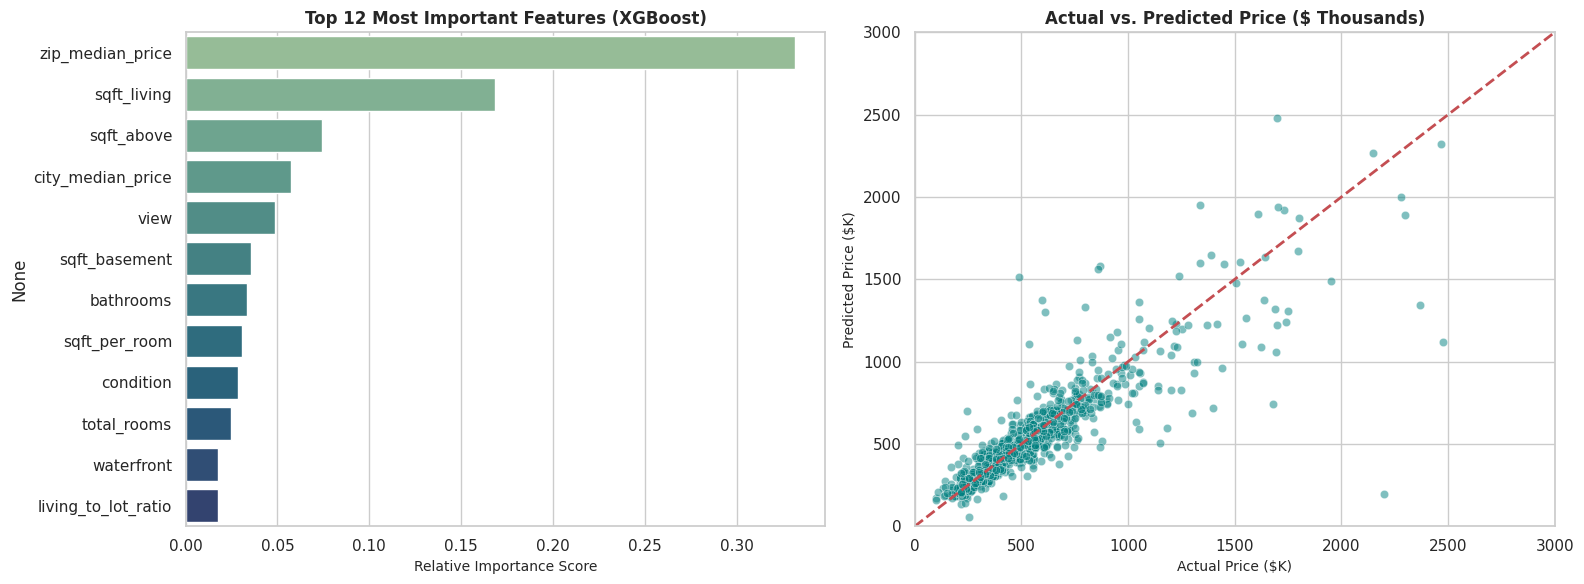

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Feature Importances
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)
sns.barplot(x=importances.values, y=importances.index, palette='crest', ax=axes[0])
axes[0].set_title("Top 12 Most Important Features (XGBoost)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Relative Importance Score", fontsize=10)

# Plot 2: Actual vs Predicted Prices ($)
sns.scatterplot(x=y_test_dollars / 1e3, y=y_pred_dollars / 1e3, alpha=0.5, color='teal', ax=axes[1])
axes[1].plot([0, 3000], [0, 3000], '--r', linewidth=2)  # Perfect prediction line
axes[1].set_title("Actual vs. Predicted Price ($ Thousands)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Actual Price ($K)", fontsize=10)
axes[1].set_ylabel("Predicted Price ($K)", fontsize=10)
axes[1].set_xlim(0, 3000)
axes[1].set_ylim(0, 3000)

plt.tight_layout()
plt.show()

### **Save Model Artifact for Deployment**

In [19]:
os.makedirs('../models', exist_ok=True)

# Save model artifact
joblib.dump(best_model, '../models/xgboost_housing_model.pkl')

# Save feature metadata
joblib.dump(X.columns.tolist(), '../models/model_features.pkl')

print("Model and feature metadata successfully saved to `models/` folder!")

Model and feature metadata successfully saved to `models/` folder!


## Modeling Summary & Results

* **Top Model:** XGBoost Regressor achieved strong predictive performance on 26 input features, reaching an **$R^2$ score of 0.8082** and a **Log-Price RMSE of 0.2316** on the 910 test set samples (trained on 3,636 samples).
* **Price Error:** The Mean Absolute Error (MAE) on actual real estate transactions is **$89,166.04 USD**.
* **Key Feature Drivers:**
  1. **Location:** `zip_median_price` and `city_median_price` dominate price prediction.
  2. **Living Space:** `sqft_living`, `sqft_above`, and `sqft_basement` are key structural factors.
  3. **Ratios & Quality:** `view`, `bathrooms`, `sqft_per_room`, `condition`, `total_rooms`, `waterfront`, and `living_to_lot_ratio` complete the top predictive signals.
* **Artifacts:** Saved model artifact to `models/xgboost_housing_model.pkl`.